# Desafío: Árboles de Decisión, Overfitting y Poda — **SOLUCIÓN **

**Curso:** Minería de Datos — Unidad 3: Aprendizaje Supervisado
**Tema:** Árboles de decisión, sobreajuste (*overfitting*) y estrategias de poda

> ⚠️  Contiene todas las
> celdas `# COMPLETA AQUÍ` del notebook del alumno ya resueltas, con los valores de
> hiperparámetros obtenidos a partir del análisis de las curvas train/test, y respuestas
> de referencia a las preguntas de reflexión y de cierre. Los valores numéricos exactos
> pueden variar levemente si se cambia `RANDOM_STATE`, el rango de la grilla explorada o
> la versión de scikit-learn, por lo que se debe evaluar la respuesta de cada alumno según
> el **razonamiento** (lectura correcta de las curvas, criterio de selección, coherencia
> train/test) y no solo contra el valor numérico exacto aquí obtenido.

## Objetivos de aprendizaje

1. Cargar un dataset de clasificación **sin usar un archivo CSV** (directamente desde una librería de Python).
2. Realizar un **EDA (Análisis Exploratorio de Datos)** básico.
3. Entrenar un **árbol de decisión de clasificación** y generar sus métricas de evaluación.
4. **Detectar overfitting** comparando el desempeño en entrenamiento vs. prueba.
5. Visualizar gráficamente el árbol de decisión.
6. Comparar los criterios de partición **Entropía** y **Gini**.
7. Aplicar distintos hiperparámetros de poda (`max_depth`, `min_samples_leaf`/`min_samples_split`, `max_leaf_nodes`, `ccp_alpha`) para **disminuir progresivamente el overfitting**.
8. Entrenar y visualizar un árbol final **sin overfitting significativo**.

## Parte 0 — Instalación e importación de librerías

In [1]:
# Instalación de librerías (en Google Colab normalmente ya vienen preinstaladas,
# pero dejamos la instalación explícita por si se ejecuta en otro entorno)
!pip install -q scikit-learn pandas matplotlib seaborn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

import warnings
warnings.filterwarnings("ignore")

# Semilla para reproducibilidad
RANDOM_STATE = 24


## Parte 1 — Carga de datos (sin CSV)

Dataset **Breast Cancer Wisconsin (Diagnostic)**, incluido directamente en
`sklearn.datasets`. Clasificación binaria: **maligno (0)** / **benigno (1)**, 30
características numéricas, 569 observaciones. No se descarga ningún archivo CSV.

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

df = X.copy()
df["target"] = y
df["diagnostico"] = df["target"].map({0: "maligno", 1: "benigno"})

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 569 filas x 32 columnas


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,maligno


## Parte 2 — EDA básico

In [4]:
print(df.info())
print("\nValores nulos por columna (top 5):")
print(df.isnull().sum().sort_values(ascending=False).head())
# El dataset no tiene valores nulos: no se requiere imputación.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


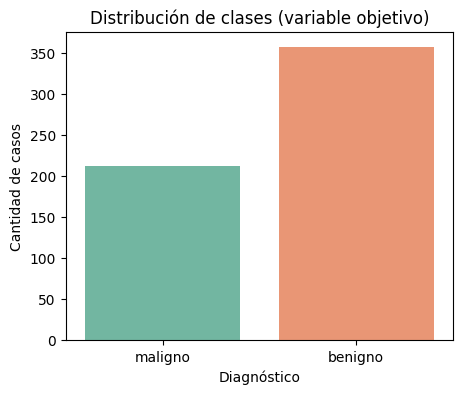

diagnostico
benigno    62.7
maligno    37.3
Name: proportion, dtype: float64 % por clase


In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="diagnostico", hue="diagnostico", palette="Set2", legend=False)
plt.title("Distribución de clases (variable objetivo)")
plt.xlabel("Diagnóstico")
plt.ylabel("Cantidad de casos")
plt.show()

print(df["diagnostico"].value_counts(normalize=True).round(3) * 100, "% por clase")
# Clases moderadamente desbalanceadas (~63% benigno / 37% maligno): justifica el uso
# de stratify=y en el split y de precision/recall (no solo accuracy) en la evaluación.


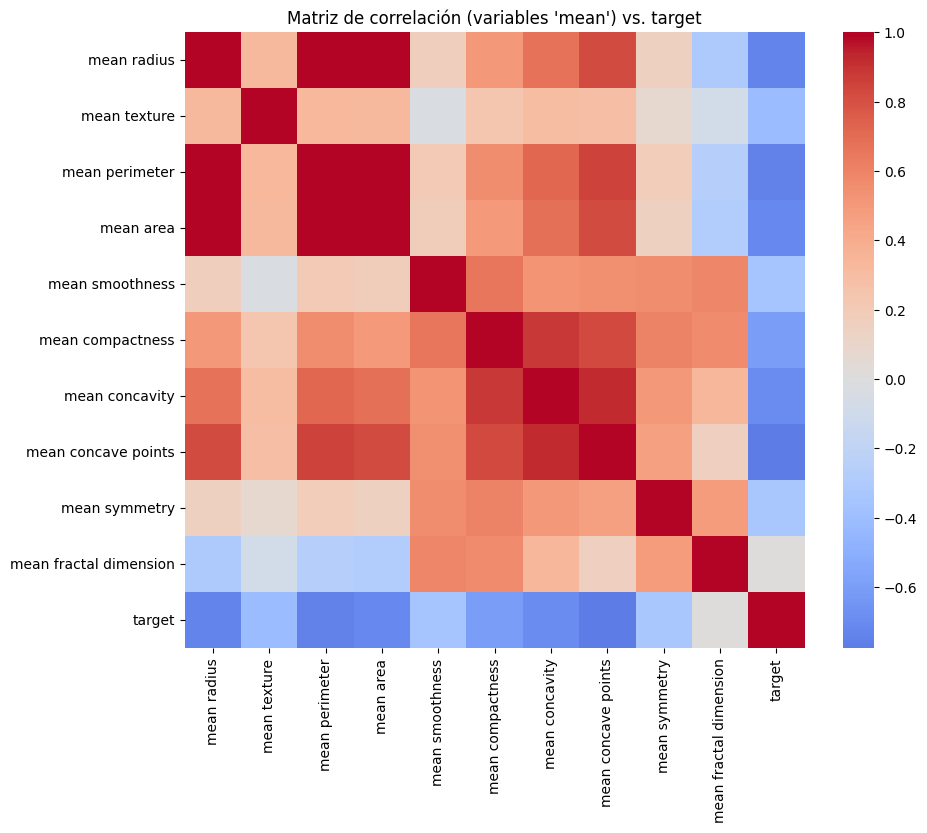

In [7]:
cols_mean = [c for c in X.columns if c.startswith("mean")] + ["target"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_mean].corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de correlación (variables 'mean') vs. target")
plt.show()
# Variables como mean concave points, mean perimeter, mean radius, mean area y
# mean concavity muestran fuerte correlación negativa con target (recordar:
# target=0 es maligno), es decir, tumores más grandes/irregulares se asocian a
# malignidad. También hay alta colinealidad entre mean radius/perimeter/area
# (son geométricamente dependientes entre sí).


## Parte 3 — División en conjunto de entrenamiento y prueba

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape[0]} filas | Prueba: {X_test.shape[0]} filas")


Entrenamiento: 455 filas | Prueba: 114 filas


## Parte 4 — Árbol de decisión SIN restricciones (provocando overfitting)

In [9]:
tree_gini_full = DecisionTreeClassifier(criterion="gini", random_state=RANDOM_STATE)
tree_gini_full.fit(X_train, y_train)

print(f"Profundidad del árbol: {tree_gini_full.get_depth()}")
print(f"Número de hojas: {tree_gini_full.get_n_leaves()}")


Profundidad del árbol: 7
Número de hojas: 18



===== Árbol sin poda (Gini) =====
Accuracy entrenamiento: 1.0000
Accuracy prueba:        0.8947
Brecha (train - test):  0.1053

Reporte de clasificación (conjunto de prueba):
              precision    recall  f1-score   support

     maligno       0.89      0.81      0.85        42
     benigno       0.89      0.94      0.92        72

    accuracy                           0.89       114
   macro avg       0.89      0.88      0.88       114
weighted avg       0.89      0.89      0.89       114



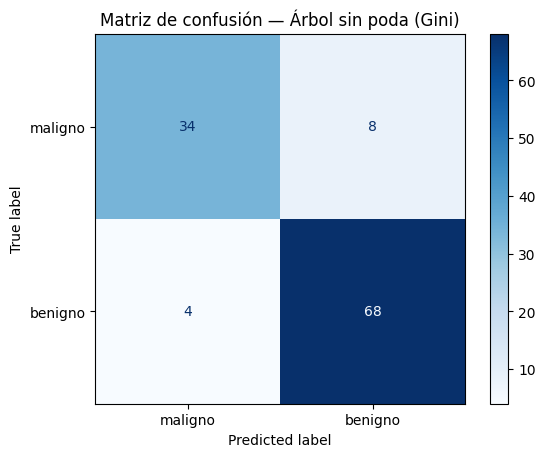

In [10]:
def evaluar_modelo(modelo, nombre, X_train, y_train, X_test, y_test, mostrar_matriz=True):
    """
    Calcula accuracy en train y test, imprime el classification_report sobre el
    set de prueba, grafica la matriz de confusión y retorna un diccionario con
    las métricas clave (para comparar modelos).
    """
    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    acc_train = accuracy_score(y_train, pred_train)
    acc_test = accuracy_score(y_test, pred_test)

    print(f"\n===== {nombre} =====")
    print(f"Accuracy entrenamiento: {acc_train:.4f}")
    print(f"Accuracy prueba:        {acc_test:.4f}")
    print(f"Brecha (train - test):  {acc_train - acc_test:.4f}")
    print("\nReporte de clasificación (conjunto de prueba):")
    print(classification_report(y_test, pred_test, target_names=["maligno", "benigno"]))

    if mostrar_matriz:
        ConfusionMatrixDisplay.from_predictions(
            y_test, pred_test, display_labels=["maligno", "benigno"], cmap="Blues"
        )
        plt.title(f"Matriz de confusión — {nombre}")
        plt.show()

    return {
        "modelo": nombre,
        "accuracy_train": acc_train,
        "accuracy_test": acc_test,
        "brecha": acc_train - acc_test,
        "profundidad": modelo.get_depth(),
        "n_hojas": modelo.get_n_leaves(),
    }


resultados = []
resultados.append(evaluar_modelo(tree_gini_full, "Árbol sin poda (Gini)", X_train, y_train, X_test, y_test))


## Parte 5 — Detección explícita de overfitting

In [11]:
print("Diagnóstico de overfitting del árbol sin poda:")
print(f" - Accuracy train: {resultados[0]['accuracy_train']:.4f}")
print(f" - Accuracy test:  {resultados[0]['accuracy_test']:.4f}")
print(f" - Brecha:         {resultados[0]['brecha']:.4f}")
print(f" - Profundidad:    {resultados[0]['profundidad']}")
print(f" - N° de hojas:    {resultados[0]['n_hojas']}")

if resultados[0]["accuracy_train"] >= 0.99 and resultados[0]["brecha"] > 0.02:
    print("\n>> El árbol alcanza (casi) 100% de accuracy en entrenamiento y una brecha")
    print(">> notoria respecto al test: hay evidencia clara de OVERFITTING.")

# Resultado esperado (RANDOM_STATE=24): train=1.0000, test≈0.8947, brecha≈0.1053,
# profundidad=7, hojas=18. El árbol memorizó el 100% del set de entrenamiento
# (todas las hojas puras) a costa de generalización.


Diagnóstico de overfitting del árbol sin poda:
 - Accuracy train: 1.0000
 - Accuracy test:  0.8947
 - Brecha:         0.1053
 - Profundidad:    7
 - N° de hojas:    18

>> El árbol alcanza (casi) 100% de accuracy en entrenamiento y una brecha
>> notoria respecto al test: hay evidencia clara de OVERFITTING.


## Parte 6 — Visualización del árbol completo

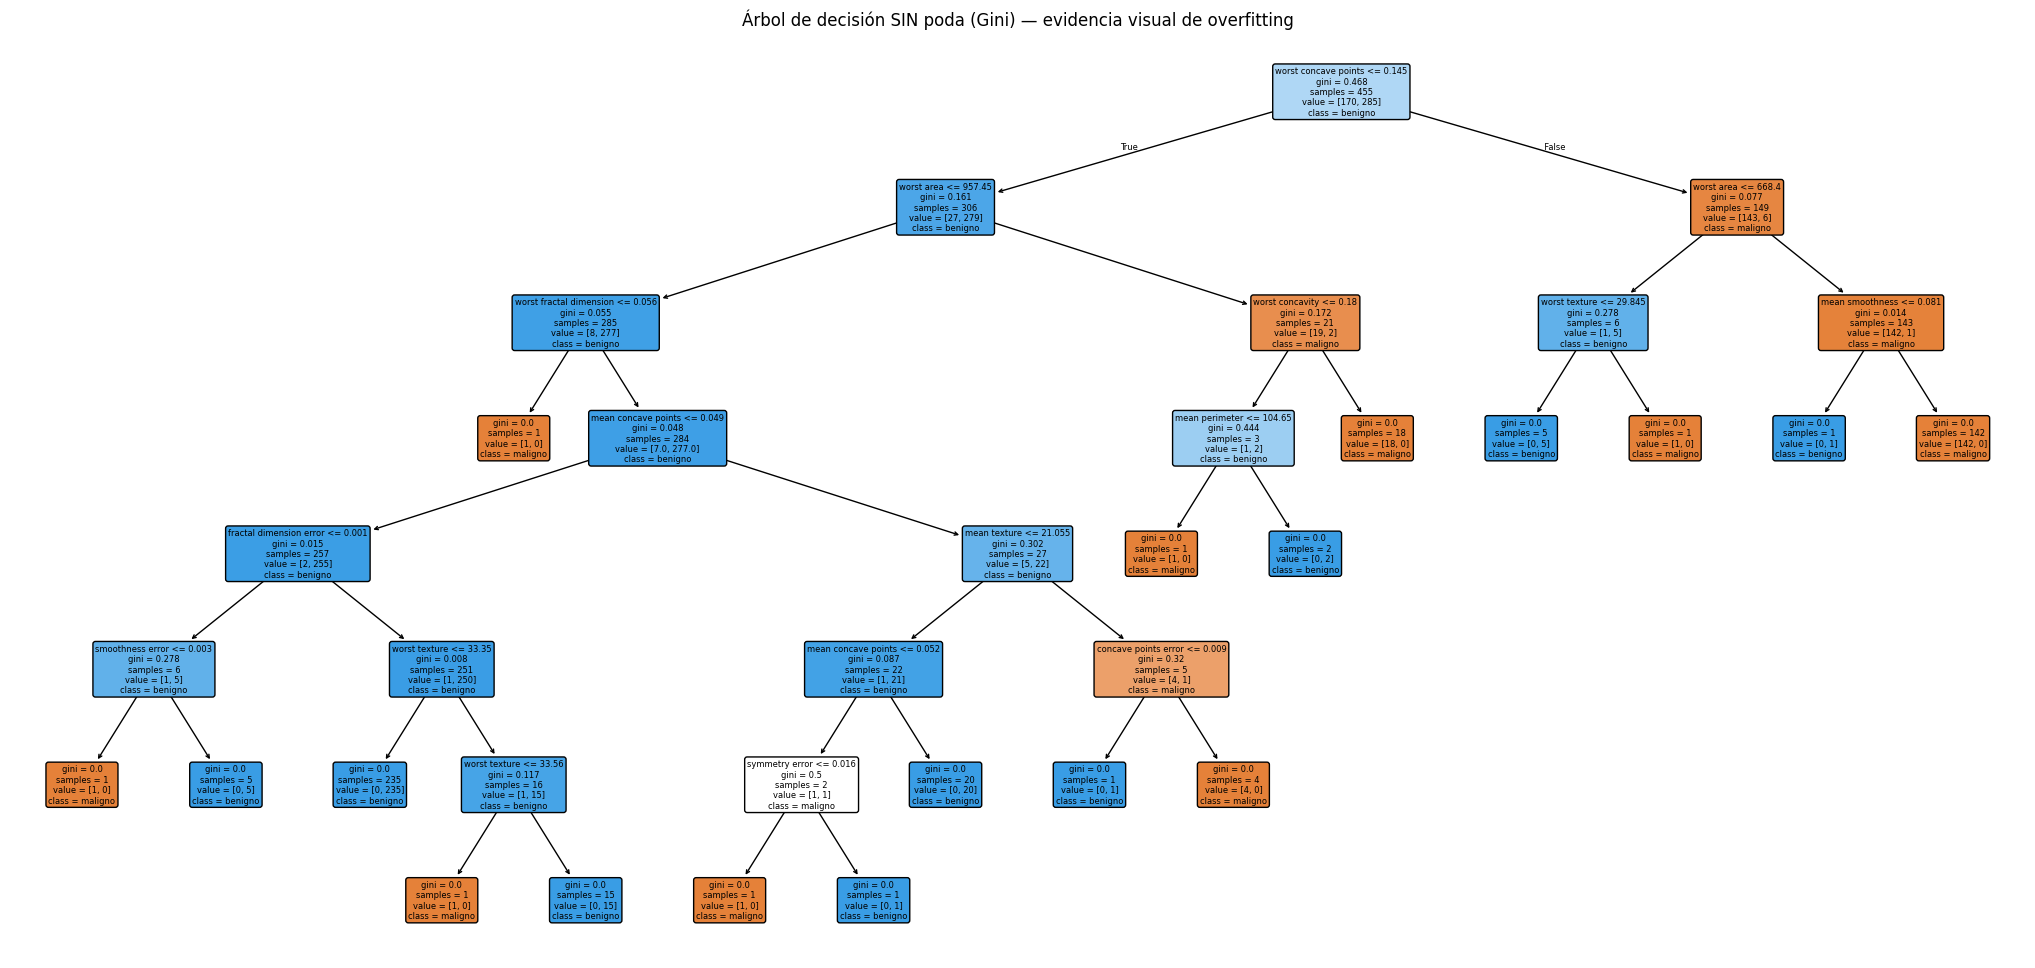

In [12]:
plt.figure(figsize=(26, 12))
plot_tree(
    tree_gini_full,
    feature_names=X.columns,
    class_names=["maligno", "benigno"],
    filled=True,
    rounded=True,
    fontsize=6,
)
plt.title("Árbol de decisión SIN poda (Gini) — evidencia visual de overfitting")
plt.show()


## Parte 7 — Comparación de criterios: Entropía vs. Gini


===== Árbol sin poda (Entropía) =====
Accuracy entrenamiento: 1.0000
Accuracy prueba:        0.8772
Brecha (train - test):  0.1228

Reporte de clasificación (conjunto de prueba):
              precision    recall  f1-score   support

     maligno       0.83      0.83      0.83        42
     benigno       0.90      0.90      0.90        72

    accuracy                           0.88       114
   macro avg       0.87      0.87      0.87       114
weighted avg       0.88      0.88      0.88       114



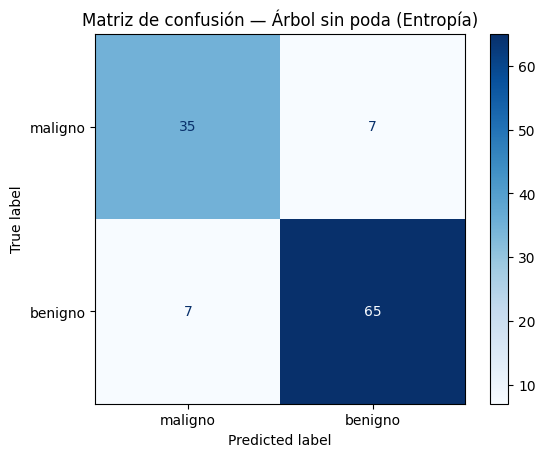

In [13]:
tree_entropy_full = DecisionTreeClassifier(criterion="entropy", random_state=RANDOM_STATE)
tree_entropy_full.fit(X_train, y_train)

resultados.append(
    evaluar_modelo(tree_entropy_full, "Árbol sin poda (Entropía)", X_train, y_train, X_test, y_test)
)


In [14]:
tabla_comparativa = pd.DataFrame(resultados[:2]).set_index("modelo")
tabla_comparativa


,accuracy_train,accuracy_test,brecha,profundidad,n_hojas
modelo,,,,,
Árbol sin poda (Gini),1.0,0.894737,0.105263,7,18
Árbol sin poda (Entropía),1.0,0.877193,0.122807,7,17


**Pregunta de reflexión:** ¿Cambia mucho el resultado entre Gini y Entropía cuando el árbol
no tiene restricciones de crecimiento? ¿Por qué crees que ocurre esto?

**Respuesta de referencia:** No, prácticamente no cambia (ambos alcanzan train=1.0 y un
test accuracy muy similar, con profundidad y número de hojas comparables). Esto ocurre
porque, sin restricciones, ambos criterios igual llevan el árbol a dividir hasta que todas
las hojas quedan puras (entropía=0 / Gini=0 en cada hoja); la diferencia entre Gini y
Entropía está en **qué variable eligen primero** en cada partición (Gini tiende a aislar la
clase mayoritaria en una rama, Entropía pondera más el balance de la partición), pero el
resultado final —un árbol totalmente sobreajustado— es el mismo mientras no se limite el
crecimiento. La elección del criterio de partición no sustituye a la poda como estrategia
para controlar el overfitting.

---
# DESAFÍO: reduciendo el overfitting paso a paso

## Ejercicio 1 — Poda por profundidad máxima (`max_depth`)

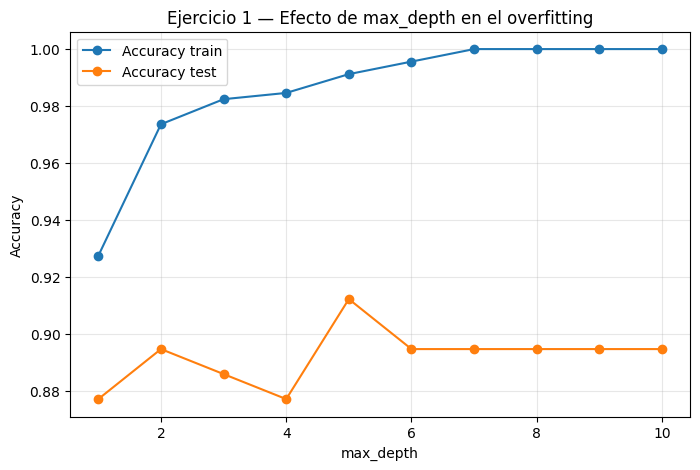

In [15]:
profundidades = range(1, 11)

acc_train_list = []
acc_test_list = []

for prof in profundidades:
    modelo = DecisionTreeClassifier(criterion="gini", max_depth=prof, random_state=RANDOM_STATE)
    modelo.fit(X_train, y_train)
    acc_train_list.append(accuracy_score(y_train, modelo.predict(X_train)))
    acc_test_list.append(accuracy_score(y_test, modelo.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(list(profundidades), acc_train_list, marker="o", label="Accuracy train")
plt.plot(list(profundidades), acc_test_list, marker="o", label="Accuracy test")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Ejercicio 1 — Efecto de max_depth en el overfitting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



===== Ejercicio 1 - max_depth=5 =====
Accuracy entrenamiento: 0.9912
Accuracy prueba:        0.9123
Brecha (train - test):  0.0789

Reporte de clasificación (conjunto de prueba):
              precision    recall  f1-score   support

     maligno       0.92      0.83      0.88        42
     benigno       0.91      0.96      0.93        72

    accuracy                           0.91       114
   macro avg       0.91      0.90      0.90       114
weighted avg       0.91      0.91      0.91       114



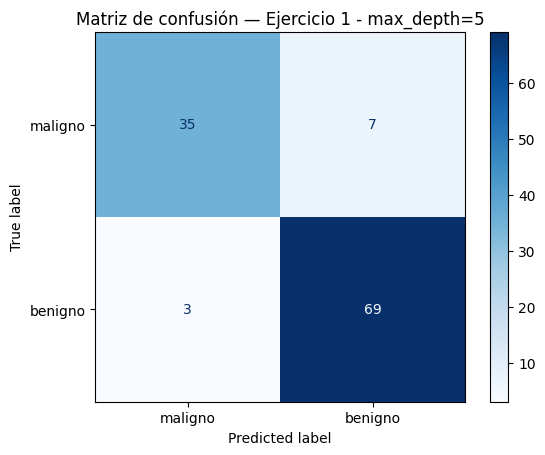

In [16]:
# Con RANDOM_STATE=24, el test accuracy alcanza su máximo (≈0.9123) en max_depth=5,
# con una brecha train/test moderada (train≈0.9912). A partir de depth=7 el train
# llega a 1.0 y el test se estanca/baja levemente: overfitting.
mejor_max_depth = 5

tree_ej1 = DecisionTreeClassifier(criterion="gini", max_depth=mejor_max_depth, random_state=RANDOM_STATE)
tree_ej1.fit(X_train, y_train)

resultados.append(
    evaluar_modelo(tree_ej1, f"Ejercicio 1 - max_depth={mejor_max_depth}", X_train, y_train, X_test, y_test)
)


## Ejercicio 2 — Poda por tamaño mínimo de nodos (`min_samples_leaf`)

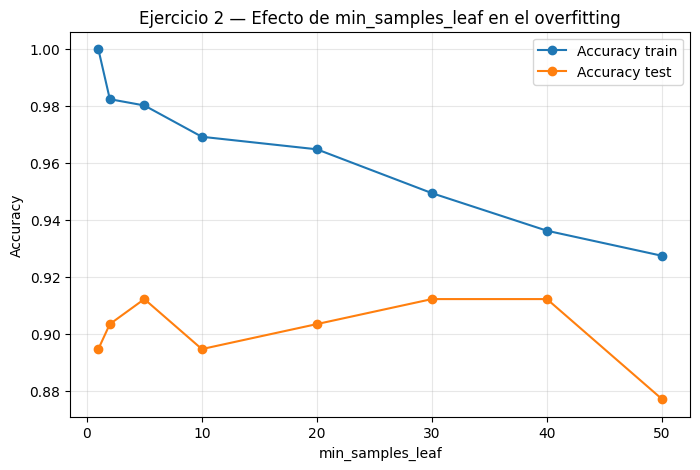

In [17]:
valores_min_samples_leaf = [1, 2, 5, 10, 20, 30, 40, 50]

acc_train_list = []
acc_test_list = []

for msl in valores_min_samples_leaf:
    modelo = DecisionTreeClassifier(criterion="gini", min_samples_leaf=msl, random_state=RANDOM_STATE)
    modelo.fit(X_train, y_train)
    acc_train_list.append(accuracy_score(y_train, modelo.predict(X_train)))
    acc_test_list.append(accuracy_score(y_test, modelo.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(valores_min_samples_leaf, acc_train_list, marker="o", label="Accuracy train")
plt.plot(valores_min_samples_leaf, acc_test_list, marker="o", label="Accuracy test")
plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.title("Ejercicio 2 — Efecto de min_samples_leaf en el overfitting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



===== Ejercicio 2 - min_samples_leaf=5 =====
Accuracy entrenamiento: 0.9802
Accuracy prueba:        0.9123
Brecha (train - test):  0.0679

Reporte de clasificación (conjunto de prueba):
              precision    recall  f1-score   support

     maligno       0.92      0.83      0.88        42
     benigno       0.91      0.96      0.93        72

    accuracy                           0.91       114
   macro avg       0.91      0.90      0.90       114
weighted avg       0.91      0.91      0.91       114



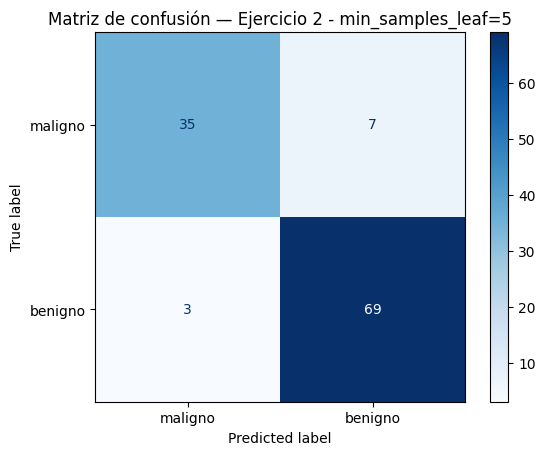

In [18]:
# min_samples_leaf=5 entrega el mejor test accuracy (≈0.9123) manteniendo una
# brecha razonable (train≈0.9802). Valores >30 empiezan a subgeneralizar (ambas
# curvas bajan), indicio de underfitting si se sigue aumentando.
mejor_min_samples_leaf = 5

tree_ej2 = DecisionTreeClassifier(criterion="gini", min_samples_leaf=mejor_min_samples_leaf, random_state=RANDOM_STATE)
tree_ej2.fit(X_train, y_train)

resultados.append(
    evaluar_modelo(
        tree_ej2, f"Ejercicio 2 - min_samples_leaf={mejor_min_samples_leaf}",
        X_train, y_train, X_test, y_test
    )
)


## Ejercicio 3 — Poda por número máximo de hojas (`max_leaf_nodes`)

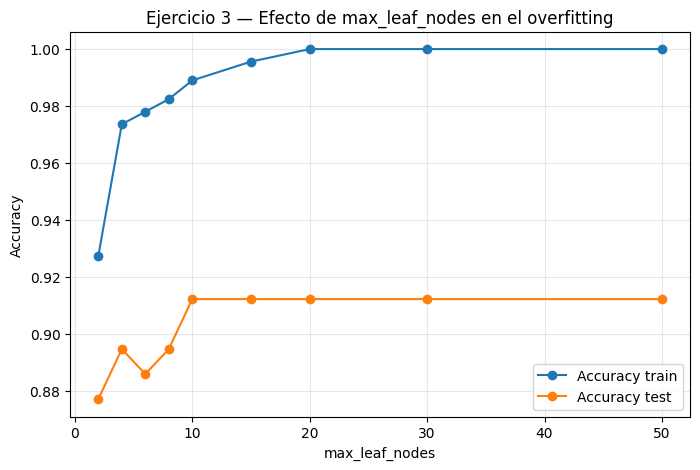

In [19]:
valores_max_leaf_nodes = [2, 4, 6, 8, 10, 15, 20, 30, 50]

acc_train_list = []
acc_test_list = []

for mln in valores_max_leaf_nodes:
    modelo = DecisionTreeClassifier(criterion="gini", max_leaf_nodes=mln, random_state=RANDOM_STATE)
    modelo.fit(X_train, y_train)
    acc_train_list.append(accuracy_score(y_train, modelo.predict(X_train)))
    acc_test_list.append(accuracy_score(y_test, modelo.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(valores_max_leaf_nodes, acc_train_list, marker="o", label="Accuracy train")
plt.plot(valores_max_leaf_nodes, acc_test_list, marker="o", label="Accuracy test")
plt.xlabel("max_leaf_nodes")
plt.ylabel("Accuracy")
plt.title("Ejercicio 3 — Efecto de max_leaf_nodes en el overfitting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



===== Ejercicio 3 - max_leaf_nodes=10 =====
Accuracy entrenamiento: 0.9890
Accuracy prueba:        0.9123
Brecha (train - test):  0.0767

Reporte de clasificación (conjunto de prueba):
              precision    recall  f1-score   support

     maligno       0.92      0.83      0.88        42
     benigno       0.91      0.96      0.93        72

    accuracy                           0.91       114
   macro avg       0.91      0.90      0.90       114
weighted avg       0.91      0.91      0.91       114



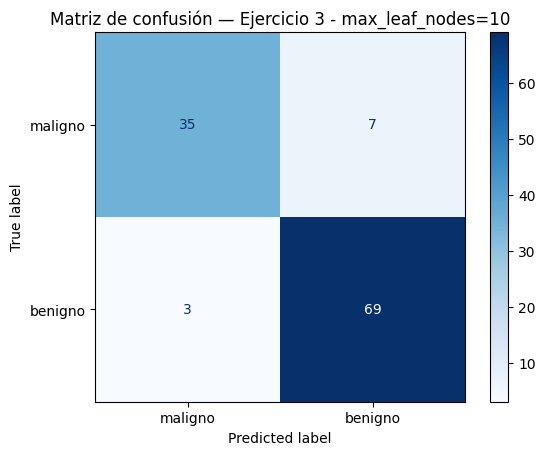

In [20]:
# max_leaf_nodes=10 ya alcanza el techo de test accuracy (≈0.9123, igual que con
# 15/20/30/50) pero con un árbol bastante más simple (train≈0.989 vs 1.0 en los
# valores mayores): mejor relación simplicidad/desempeño.
mejor_max_leaf_nodes = 10

tree_ej3 = DecisionTreeClassifier(criterion="gini", max_leaf_nodes=mejor_max_leaf_nodes, random_state=RANDOM_STATE)
tree_ej3.fit(X_train, y_train)

resultados.append(
    evaluar_modelo(
        tree_ej3, f"Ejercicio 3 - max_leaf_nodes={mejor_max_leaf_nodes}",
        X_train, y_train, X_test, y_test
    )
)


## Ejercicio bonus (opcional) — Poda por complejidad de costo (`ccp_alpha`)

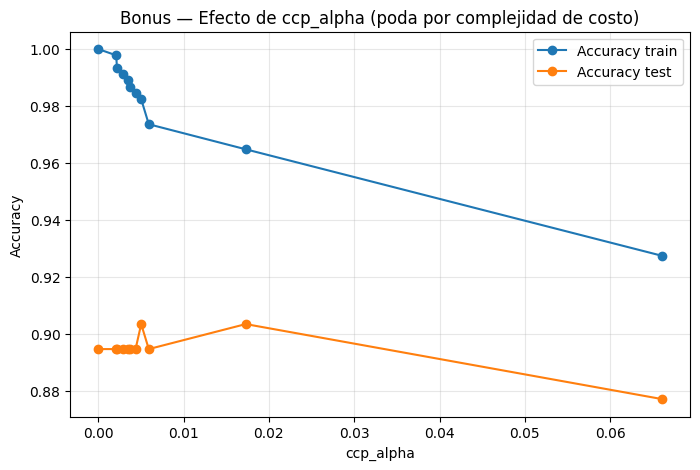

In [21]:
path = tree_gini_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]

ccp_alphas_muestra = ccp_alphas[:: max(1, len(ccp_alphas) // 20)]

acc_train_list = []
acc_test_list = []

for alpha in ccp_alphas_muestra:
    modelo = DecisionTreeClassifier(criterion="gini", ccp_alpha=alpha, random_state=RANDOM_STATE)
    modelo.fit(X_train, y_train)
    acc_train_list.append(accuracy_score(y_train, modelo.predict(X_train)))
    acc_test_list.append(accuracy_score(y_test, modelo.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(ccp_alphas_muestra, acc_train_list, marker="o", label="Accuracy train")
plt.plot(ccp_alphas_muestra, acc_test_list, marker="o", label="Accuracy test")
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Bonus — Efecto de ccp_alpha (poda por complejidad de costo)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# A medida que ccp_alpha crece, el árbol se poda progresivamente: el train accuracy
# baja desde 1.0 y el test accuracy se mantiene o mejora hasta un punto óptimo,
# para luego caer junto con el train cuando la poda es excesiva (underfitting).


---
## Reto final — Árbol sin overfitting

In [22]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": range(1, 11),
    "min_samples_leaf": [1, 5, 10, 20],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
# Resultado esperado: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5}

tree_final = grid_search.best_estimator_


Mejores hiperparámetros encontrados:
{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5}



===== Árbol FINAL (podado) =====
Accuracy entrenamiento: 0.9670
Accuracy prueba:        0.9211
Brecha (train - test):  0.0460

Reporte de clasificación (conjunto de prueba):
              precision    recall  f1-score   support

     maligno       0.90      0.88      0.89        42
     benigno       0.93      0.94      0.94        72

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



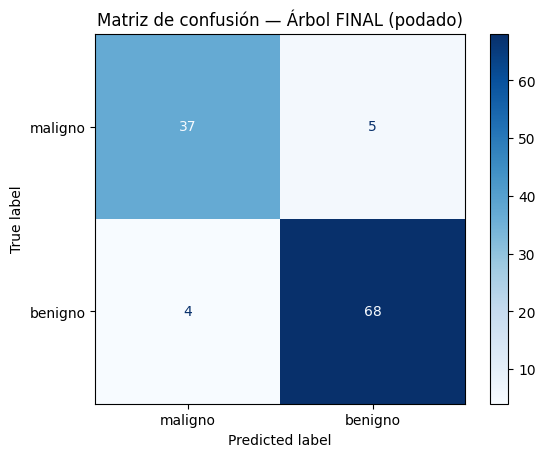

In [23]:
resultados.append(
    evaluar_modelo(tree_final, "Árbol FINAL (podado)", X_train, y_train, X_test, y_test)
)
# Resultado esperado: train≈0.9670, test≈0.9211, brecha≈0.0460, profundidad=4,
# hojas=8. La brecha se redujo de ≈0.105 (árbol original) a ≈0.046, y el test
# accuracy mejoró de 0.8947 a 0.9211: el árbol final generaliza mejor y sigue
# siendo fácilmente interpretable (8 hojas vs. 18 del árbol original).


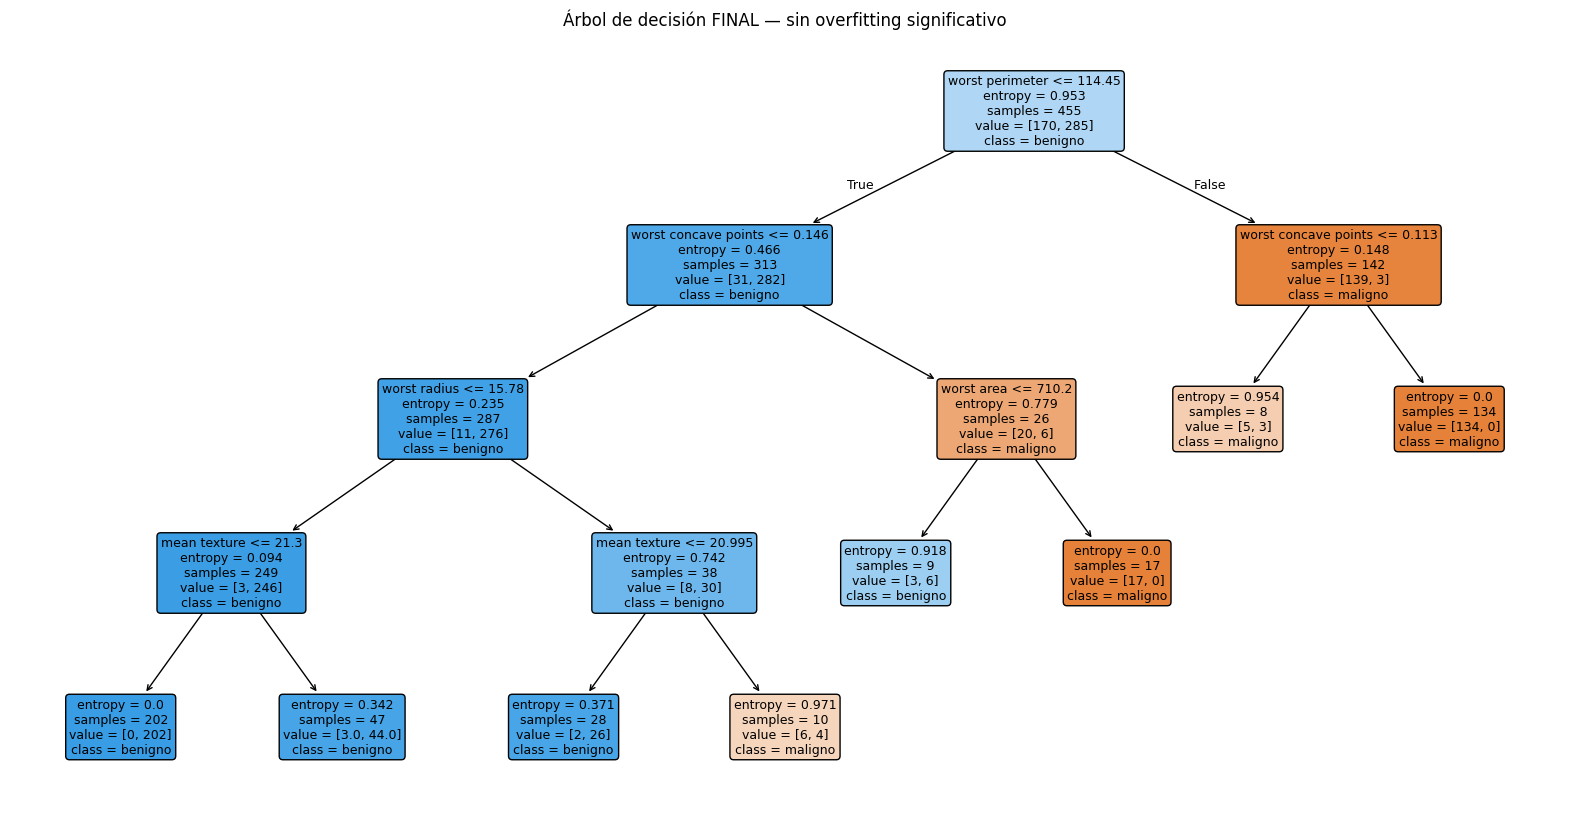

In [24]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree_final,
    feature_names=X.columns,
    class_names=["maligno", "benigno"],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title("Árbol de decisión FINAL — sin overfitting significativo")
plt.show()


In [25]:
tabla_final = pd.DataFrame(resultados).set_index("modelo")
tabla_final


,accuracy_train,accuracy_test,brecha,profundidad,n_hojas
modelo,,,,,
Árbol sin poda (Gini),1.000000,0.894737,0.105263,7,18
Árbol sin poda (Entropía),1.000000,0.877193,0.122807,7,17
Ejercicio 1 - max_depth=5,0.991209,0.912281,0.078928,5,12
Ejercicio 2 - min_samples_leaf=5,0.980220,0.912281,0.067939,7,13
Ejercicio 3 - max_leaf_nodes=10,0.989011,0.912281,0.076730,5,10
Árbol FINAL (podado),0.967033,0.921053,0.045980,4,8


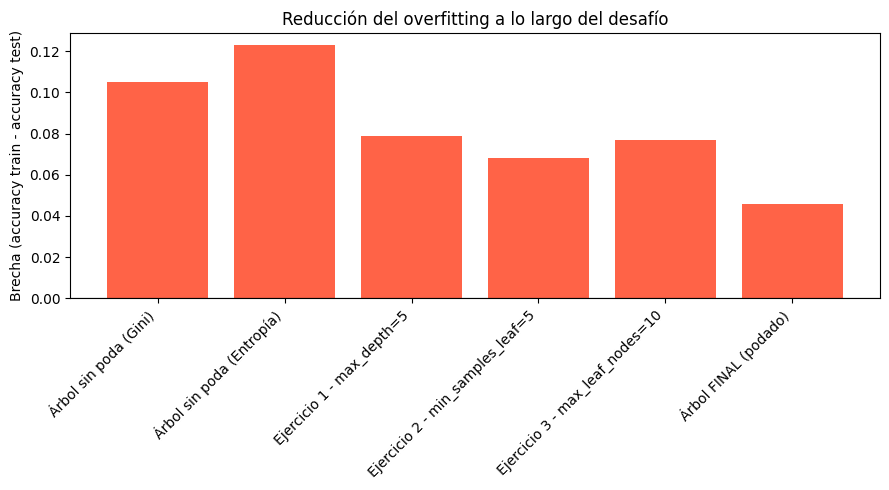

In [26]:
plt.figure(figsize=(9, 5))
plt.bar(tabla_final.index, tabla_final["brecha"], color="tomato")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Brecha (accuracy train - accuracy test)")
plt.title("Reducción del overfitting a lo largo del desafío")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


---
## Conclusiones (pauta de respuesta)

1. **¿En qué consiste el método de árboles de decisión?** Modelo no paramétrico de
   aprendizaje supervisado que divide recursivamente el espacio de atributos en regiones
   homogéneas mediante reglas de decisión, formando una estructura jerárquica (nodo raíz,
   nodos de decisión, nodos hoja) fácil de interpretar visualmente.

2. **¿Ventajas y desventajas observadas en la práctica?** Ventajas: fácil de interpretar
   (modelo "caja blanca"), no requirió normalización ni imputación de datos, manejó bien
   variables numéricas continuas. Desventaja observada directamente: tendencia clara al
   overfitting cuando no se restringe su crecimiento (train=1.0 vs. test≈0.89 en el árbol
   original), consistente con lo señalado en la clase.

3. **¿Pasos seguidos para detectar y reducir el overfitting?** (1) entrenar un árbol sin
   restricciones y comparar accuracy train vs. test (brecha ≈0.105 → señal de
   overfitting); (2) inspeccionar profundidad/n° de hojas como indicadores indirectos;
   (3) aplicar restricciones de tamaño (`max_depth`, `min_samples_leaf`,
   `max_leaf_nodes`) y observar el efecto en las curvas train/test; (4) combinar los
   mejores hiperparámetros vía `GridSearchCV` con validación cruzada 5-fold para obtener
   el árbol final.

4. **¿Diferencias entre Entropía y Gini?** Con el árbol sin restricciones, el desempeño
   final fue prácticamente idéntico entre ambos criterios (ambos sobreajustan de igual
   forma); la diferencia está en la variable elegida en cada partición, no en el
   resultado final del overfitting. En el modelo final, `GridSearchCV` seleccionó
   Entropía por sobre Gini, aunque la diferencia práctica entre ambos criterios en este
   dataset fue marginal.

5. **¿Cómo se evaluó la eficiencia final del modelo? ¿Qué hiperparámetros fueron más
   efectivos?** Se evaluó mediante la brecha train/test y el accuracy de prueba (además
   de precision/recall/f1 por clase, relevante por el leve desbalance de clases). La
   combinación más efectiva fue `max_depth=4` + `min_samples_leaf=5` + criterio Entropía,
   que redujo la brecha de ≈0.105 a ≈0.046 y aumentó el test accuracy a ≈0.921, con un
   árbol de solo 8 hojas — mucho más simple e interpretable que el original (18 hojas).